In [11]:
import numpy as np

In [12]:
x_data = [2.5,0.5,2.2,1.9,3.0,2.3,2.0,1.0,1.5,1.1]
y_data = [2.0,0.7,2.9,2.2,2.8,2.7,1.6,1.1,1.6,0.9]
data_matrix    =    np.array([x_data,y_data]).T
print(data_matrix)

[[2.5 2. ]
 [0.5 0.7]
 [2.2 2.9]
 [1.9 2.2]
 [3.  2.8]
 [2.3 2.7]
 [2.  1.6]
 [1.  1.1]
 [1.5 1.6]
 [1.1 0.9]]


In [32]:
# standardizing the data
def data_center(data_matrix):
    """
    use- pass a 2d matrix, the function returns centered data and a 1d array containing the centers
    """
    centered_data    =    np.zeros((data_matrix.shape[0],data_matrix.shape[1]))
    means    =    []
    for j in range(data_matrix.shape[1]):
        #print(data_matrix[:,j])
        mu    =    np.sum(data_matrix[:,j])/len(data_matrix[:,j])
        centered_data[:,j]    =    data_matrix[:,j] - mu
        means.append(mu)
    return centered_data, np.asarray(means)

def std_finder(data_matrix):
    scaled_data  =    np.zeros((data_matrix.shape[0],data_matrix.shape[1]))
    std_array    =    []
    for j in range(data_matrix.shape[1]):
        mu    =    np.sum(data_matrix[:,j])/len(data_matrix[:,j])
        std_j    =    np.sqrt(np.sum(np.square(data_matrix[:,j]-mu))/len(data_matrix[:,j]))
        scaled_data[:,j]    =    data_matrix[:,j]/std_j
        std_array.append(std_j)
    return scaled_data, np.asarray(std_array)

def standardize_data(data_matrix):
    center_data, centers    =    data_center(data_matrix)
    scaled_data, stds       =    std_finder(center_data)
    return scaled_data
centered_data, centers    =    data_center(data_matrix=data_matrix)
data_std        =    standardize_data(data_matrix=data_matrix)
print(centerd_data, "\n", data_std)

[[ 0.7   0.15]
 [-1.3  -1.15]
 [ 0.4   1.05]
 [ 0.1   0.35]
 [ 1.2   0.95]
 [ 0.5   0.85]
 [ 0.2  -0.25]
 [-0.8  -0.75]
 [-0.3  -0.25]
 [-0.7  -0.95]] 
 [[ 0.96152395  0.19721483]
 [-1.78568733 -1.51198039]
 [ 0.54944226  1.38050383]
 [ 0.13736056  0.46016794]
 [ 1.64832677  1.24902728]
 [ 0.68680282  1.11755072]
 [ 0.27472113 -0.32869139]
 [-1.09888451 -0.98607417]
 [-0.41208169 -0.32869139]
 [-0.96152395 -1.24902728]]


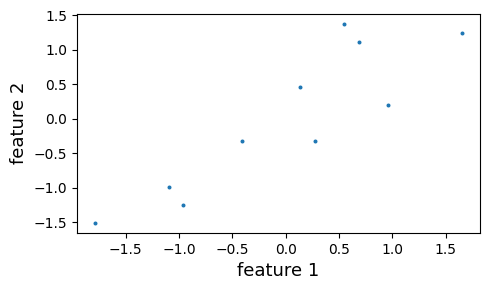

In [33]:
# plotting the scatter plot of the centered data
import matplotlib.pyplot as plt
figsize    =    (5,3)
plt.figure(1, figsize=figsize)
plt.scatter(data_std[:,0], data_std[:,1], s=3.5)
plt.xlabel(f"feature 1",fontsize=13)
plt.ylabel(f"feature 2",fontsize=13)
plt.tight_layout()
plt.show()

In [56]:
# performing the PCA on this centered data
from sklearn.decomposition import PCA
pca_data    =    PCA(n_components=2)
pca_data.fit(centered_data)
principal_components    =    pca_data.components_
explained_variance      =    pca_data.explained_variance_
print("principal components:\n",principal_components)
print("explained variance :\n",explained_variance)

principal components:
 [[ 0.68944584  0.72433724]
 [ 0.72433724 -0.68944584]]
explained variance :
 [1.16205386 0.0696128 ]


[2.22963893 2.34247626]
[ 0.57333259 -0.5457151 ]


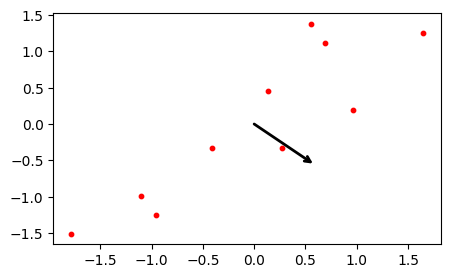

In [57]:
# plotting the data with principal components
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->',
                    linewidth=2,
                    shrinkA=0, shrinkB=0)
    ax.annotate('', v1, v0, arrowprops=arrowprops)

# plot data
plt.figure(2, figsize=figsize)
plt.scatter(data_std[:, 0], data_std[:, 1], c='r',s=10)
for length, vector in zip(pca_data.explained_variance_, pca_data.components_):
    #print(length, vector)
    v = vector * 3 * np.sqrt(length)
    print(v)
    draw_vector(pca_data.mean_, pca_data.mean_ + v)
plt.show()
#plt.axis('equal');